In [ ]:
import pandas as pd

file_names= ['feed_forward_basic_kfold_metrics.csv']

file_names = ['../models/' + a for a in file_names]
df = pd.DataFrame()

dfs = []

for filename in file_names:
    df = pd.read_csv(filename)
    df['val_auc'] = df['val_auc'] - df['val_auc'].mean()
    df['val_loss'] = df['val_loss'] - df['val_loss'].mean()
    df['val_sens'] = df['val_sens'] - df['val_sens'].mean()
    df['val_spec'] = df['val_spec'] - df['val_spec'].mean()
    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)



<Figure size 640x480 with 0 Axes>

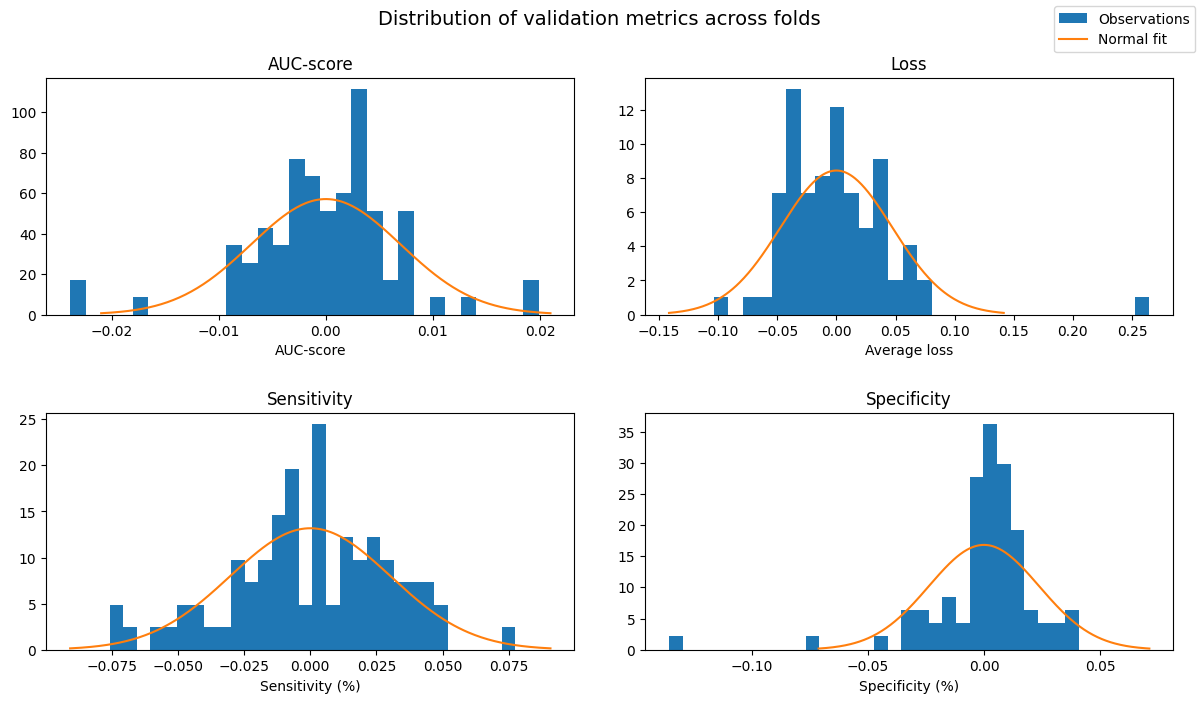

In [6]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import norm
import numpy as np
AUCs = df['val_auc']
loss = df['val_loss']
spec = df['val_spec']
sens = df['val_sens']

plt.figure()
fig, ((ax1, ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('Distribution of validation metrics across folds', fontsize=14, y=1.02)

plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=5.0, w_pad=2.0)
ax1.hist(df['val_auc'].sort_values(),bins=30,density=True,label='Observations')
mu = np.mean(AUCs)
std = np.std(AUCs)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax1.set_title('AUC-score')
ax1.plot(x,y,label='Normal fit')
ax1.set_xlabel('AUC-score')

ax2.hist(df['val_loss'].sort_values(),bins=30,density=True)
mu = np.mean(loss)
std = np.std(loss)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax2.set_title('Loss')
ax2.plot(x,y)
ax2.set_xlabel('Average loss')

ax3.hist(df['val_sens'].sort_values(),bins=30,density=True)
mu = np.mean(sens)
std = np.std(sens)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax3.set_title('Sensitivity')
ax3.set_xlabel('Sensitivity (%)')
ax3.plot(x,y)

ax4.hist(df['val_spec'].sort_values(),bins=30,density=True)
mu = np.mean(spec)
std = np.std(spec)
x = np.linspace(mu-3*std,mu+3*std,300)
y = norm.pdf(x,mu,std)
ax4.plot(x,y)
ax4.set_title('Specificity')
ax4.set_xlabel('Specificity (%)')
fig.legend()
plt.show()

In [1]:
from functions.evaluation import generate_latex_table
import pandas as pd
df = pd.read_csv('../models/feed_forward_basic_kfold_metrics.csv')
string = generate_latex_table(df)
print(string)


\begin{table}[H]
\begin{center}
\begin{minipage}{0.45\textwidth}
    \centering
    \begin{tabular}{cc|cc}
      \toprule
      & & \multicolumn{2}{c}{Predicted} \\
      & & Neg. & Pos. \\
      \midrule
      \multirow{2}{*}{\rotatebox[origin=c]{90}{Actual}}
      & Neg. & $1814 \pm 26$ & $71 \pm 26$ \\[0.1em]
      & Pos. & $40 \pm 11$ & $229 \pm 11$ \\
      \addlinespace[0.6em]
      \bottomrule
    \end{tabular}
\end{minipage}%
\begin{minipage}{0.45\textwidth}
    \centering
    \begin{tabular}{lr}
      \toprule
      Accuracy    & $94.84 \pm 1.04$ \% \\
      AUC         & $0.9636 \pm 0.0129$ \\
      Sensitivity & $0.8521 \pm 0.0417$ \\
      Specificity & $0.9622 \pm 0.0138$ \\
      Avg. Val. loss & $0.2584 \pm 0.1007$ \\
      \bottomrule
    \end{tabular}
\end{minipage}
\end{center}
\caption{Caption}
\label{label}
\end{table}

